# 01 - Compile Results
This notebook compiles and aggregates results across all experiments for comparison.

In [22]:
# Import required libraries
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [23]:
# Set up paths
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
ANALYSIS_OUTPUT_DIR = PROJECT_ROOT / 'data' / 'analysis'
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results Directory: {RESULTS_DIR}")
print(f"Analysis Output: {ANALYSIS_OUTPUT_DIR}")

Results Directory: /home/sjoon/projects/brain_connectivity_classifier/data/results
Analysis Output: /home/sjoon/projects/brain_connectivity_classifier/data/analysis


In [24]:
# Helper functions
def load_json(filepath):
    """Load JSON file safely"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_csv(filepath):
    """Load CSV file safely"""
    try:
        return pd.read_csv(filepath)
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

## 1. Compile Cross-Validation Performance

In [29]:
# Compile CV performance across all strategies
cv_performance = []

# Full connectivity models
for strategy in ['multinomial', 'ovo', 'ovr']:
    metrics_path = RESULTS_DIR / 'full_connectivity_analysis' / strategy / 'overall_metrics.json'
    fold_metrics_path = RESULTS_DIR / 'full_connectivity_analysis' / strategy / 'fold_metrics.json'
    
    metrics = load_json(metrics_path)
    fold_metrics = load_json(fold_metrics_path)
    
    if metrics:
        # Calculate std from fold metrics if available
        accuracy_std = 0
        balanced_acc_std = 0
        
        if fold_metrics:
            fold_accuracies = [f['accuracy'] for f in fold_metrics]
            fold_balanced_accs = [f['balanced_accuracy'] for f in fold_metrics]
            accuracy_std = np.std(fold_accuracies)
            balanced_acc_std = np.std(fold_balanced_accs)
        
        cv_performance.append({
            'Analysis': 'Full Connectivity',
            'Strategy': strategy.upper(),
            'Accuracy': metrics.get('accuracy', 0),
            'Accuracy_Std': accuracy_std,
            'Balanced_Accuracy': metrics.get('balanced_accuracy', 0),
            'Balanced_Accuracy_Std': balanced_acc_std,
            'N_Samples': metrics.get('n_samples', 0),
            'N_Classes': metrics.get('n_classes', 0),
            'Top_3_Accuracy': metrics.get('top_3_accuracy', 0),
            'Top_5_Accuracy': metrics.get('top_5_accuracy', 0),
            'Top_10_Accuracy': metrics.get('top_10_accuracy', 0)
        })

cv_performance_df = pd.DataFrame(cv_performance)
print("\nCross-Validation Performance:")
print(cv_performance_df.to_string(index=False))


Cross-Validation Performance:
         Analysis    Strategy  Accuracy  Accuracy_Std  Balanced_Accuracy  Balanced_Accuracy_Std  N_Samples  N_Classes  Top_3_Accuracy  Top_5_Accuracy  Top_10_Accuracy
Full Connectivity MULTINOMIAL  0.924126      0.002439           0.924126               0.002439      51968        232        0.973137        0.983336         0.991399
Full Connectivity         OVO  0.868785      0.003630           0.868785               0.003630      51968        232        0.940714        0.961573         0.980392
Full Connectivity         OVR  0.931708      0.001876           0.931708               0.001876      51968        232        0.974754        0.983721         0.990475


In [31]:
# Add hemisphere-specific results
hemi_cv_performance = []

for hemisphere in ['left_hemisphere', 'right_hemisphere']:
    for strategy in ['multinomial', 'ovo', 'ovr']:
        metrics_path = RESULTS_DIR / 'hemisphere_analysis' / hemisphere / strategy / 'overall_metrics.json'
        fold_metrics_path = RESULTS_DIR / 'hemisphere_analysis' / hemisphere / strategy / 'fold_metrics.json'
        
        metrics = load_json(metrics_path)
        fold_metrics = load_json(fold_metrics_path)
        
        if metrics:
            hemi_name = 'Left' if 'left' in hemisphere else 'Right'
            
            # Calculate std from fold metrics if available
            accuracy_std = 0
            balanced_acc_std = 0
            
            if fold_metrics:
                fold_accuracies = [f['accuracy'] for f in fold_metrics]
                fold_balanced_accs = [f['balanced_accuracy'] for f in fold_metrics]
                accuracy_std = np.std(fold_accuracies)
                balanced_acc_std = np.std(fold_balanced_accs)
            
            hemi_cv_performance.append({
                'Analysis': f'{hemi_name} Hemisphere',
                'Strategy': strategy.upper(),
                'Accuracy': metrics.get('accuracy', 0),
                'Accuracy_Std': accuracy_std,
                'Balanced_Accuracy': metrics.get('balanced_accuracy', 0),
                'Balanced_Accuracy_Std': balanced_acc_std,
                'N_Samples': metrics.get('n_samples', 0),
                'N_Classes': metrics.get('n_classes', 0),
                'Top_3_Accuracy': metrics.get('top_3_accuracy', 0),
                'Top_5_Accuracy': metrics.get('top_5_accuracy', 0),
                'Top_10_Accuracy': metrics.get('top_10_accuracy', 0)
            })

hemi_cv_df = pd.DataFrame(hemi_cv_performance)
print("\nHemisphere Cross-Validation Performance:")
print(hemi_cv_df.to_string(index=False))


Hemisphere Cross-Validation Performance:
        Analysis    Strategy  Accuracy  Accuracy_Std  Balanced_Accuracy  Balanced_Accuracy_Std  N_Samples  N_Classes  Top_3_Accuracy  Top_5_Accuracy  Top_10_Accuracy
 Left Hemisphere MULTINOMIAL  0.918180      0.004778           0.918180               0.004778          0          0               0        0.982682         0.992495
 Left Hemisphere         OVO  0.881427      0.007082           0.881427               0.007082          0          0               0        0.970251         0.986415
 Left Hemisphere         OVR  0.922645      0.004891           0.922645               0.004891          0          0               0        0.983721         0.992649
Right Hemisphere MULTINOMIAL  0.913562      0.002358           0.913562               0.002358          0          0               0        0.982066         0.992303
Right Hemisphere         OVO  0.875269      0.004479           0.875269               0.004479          0          0            

In [32]:
# Combine all CV results
all_cv_df = pd.concat([cv_performance_df, hemi_cv_df], ignore_index=True)
all_cv_df.to_csv(ANALYSIS_OUTPUT_DIR / 'compiled_cv_performance.csv', index=False)
print(f"\nSaved compiled CV performance to: {ANALYSIS_OUTPUT_DIR / 'compiled_cv_performance.csv'}")


Saved compiled CV performance to: /home/sjoon/projects/brain_connectivity_classifier/data/analysis/compiled_cv_performance.csv


## 2. Compile Task Testing Performance

In [37]:
# Compile task testing performance
task_performance = []

# Full connectivity task testing
for strategy in ['multinomial', 'ovo', 'ovr']:
    if strategy == 'multinomial':
        task_dir = 'task_testing'
    else:
        task_dir = f'task_testing_{strategy}'
    
    summary_path = RESULTS_DIR / 'full_connectivity_analysis' / task_dir / 'task_testing_summary.json'
    summary = load_json(summary_path)
    
    if summary:
        task_performance.append({
            'Analysis': 'Full Connectivity',
            'Strategy': strategy.upper(),
            'Accuracy': summary.get('task_test_accuracy', summary.get('task_accuracy', 0)),
            'Balanced_Accuracy': summary.get('task_balanced_accuracy', 0),
            'N_Samples': summary.get('n_task_samples', summary.get('n_samples', 0)),
            'N_Subjects': summary.get('n_task_subjects', 0),
            'Top_5_Accuracy': summary.get('task_top_5_accuracy', 0),
            'Accuracy_Drop': summary.get('accuracy_drop', 0),
            'Rest_Train_Accuracy': summary.get('rest_train_accuracy', 0)
        })

task_performance_df = pd.DataFrame(task_performance)
print("\nTask Testing Performance (Full Connectivity):")
print(task_performance_df.to_string(index=False))


Task Testing Performance (Full Connectivity):
         Analysis    Strategy  Accuracy  Balanced_Accuracy  N_Samples  N_Subjects  Top_5_Accuracy  Accuracy_Drop  Rest_Train_Accuracy
Full Connectivity MULTINOMIAL  0.892392           0.892392      46400         200        0.972608       0.097813             0.990206
Full Connectivity         OVO  0.830496           0.830496          0         200        0.000000       0.169504             1.000000
Full Connectivity         OVR  0.896336           0.896336      46400         200        0.970711       0.089309             0.985645


In [66]:
# Add hemisphere task testing
hemi_task_performance = []

for hemisphere in ['left_hemisphere', 'right_hemisphere']:
    for strategy in ['multinomial', 'ovo', 'ovr']:
        task_dir = f'task_testing_{strategy}'
        summary_path = RESULTS_DIR / 'hemisphere_analysis' / hemisphere / task_dir / 'task_testing_summary.json'
        summary = load_json(summary_path)
        
        if summary:
            hemi_name = 'Left' if 'left' in hemisphere else 'Right'
            
            hemi_task_performance.append({
                'Analysis': f'{hemi_name} Hemisphere',
                'Strategy': strategy.upper(),
                'Accuracy': summary.get('task_test_accuracy', 0),
                'Balanced_Accuracy': summary.get('task_balanced_accuracy', 0),
                'N_Samples': summary.get('n_task_samples', 0),
                'N_Subjects': summary.get('n_task_subjects', 0),
                'Top_5_Accuracy': summary.get('task_top_5_accuracy', 0),
                'Accuracy_Drop': summary.get('accuracy_drop', 0),
                'Rest_Train_Accuracy': summary.get('rest_train_accuracy', 0)
            })

hemi_task_df = pd.DataFrame(hemi_task_performance)
print("\nTask Testing Performance (Hemispheres):")
print(hemi_task_df.to_string(index=False))


Task Testing Performance (Hemispheres):
        Analysis    Strategy  Accuracy  Balanced_Accuracy  N_Samples  N_Subjects  Top_5_Accuracy  Accuracy_Drop  Rest_Train_Accuracy
 Left Hemisphere MULTINOMIAL  0.869310           0.869310      23200         200        0.970388       0.108022             0.977332
 Left Hemisphere         OVO  0.835862           0.835862      23200         200        0.954138       0.164138             1.000000
 Left Hemisphere         OVR  0.875690           0.875690      23200         200        0.969095       0.089828             0.965517
Right Hemisphere MULTINOMIAL  0.863060           0.863060      23200         200        0.965690       0.114310             0.977371
Right Hemisphere         OVO  0.823578           0.823578      23200         200        0.948578       0.176115             0.999692
Right Hemisphere         OVR  0.871034           0.871034      23200         200        0.964009       0.090634             0.961669


In [67]:
# Combine all task testing results
all_task_df = pd.concat([task_performance_df, hemi_task_df], ignore_index=True)
all_task_df.to_csv(ANALYSIS_OUTPUT_DIR / 'compiled_task_performance.csv', index=False)
print(f"\nSaved compiled task performance to: {ANALYSIS_OUTPUT_DIR / 'compiled_task_performance.csv'}")


Saved compiled task performance to: /home/sjoon/projects/brain_connectivity_classifier/data/analysis/compiled_task_performance.csv


In [68]:
all_task_df.head(2)

,Analysis,Strategy,Accuracy,Balanced_Accuracy,N_Samples,N_Subjects,Top_5_Accuracy,Accuracy_Drop,Rest_Train_Accuracy
0,Full Connectivity,MULTINOMIAL,0.892392,0.892392,46400,200,0.972608,0.097813,0.990206
1,Full Connectivity,OVO,0.830496,0.830496,0,200,0.000000,0.169504,1.000000


## 3. Compile Network-Level Performance

In [69]:
# Compile network-level metrics from CV
network_cv_data = []

for strategy in ['multinomial', 'ovo', 'ovr']:
    network_path = RESULTS_DIR / 'full_connectivity_analysis' / strategy / 'network_metrics.csv'
    network_df = load_csv(network_path)
    
    if network_df is not None:
        network_df['Analysis'] = 'Full Connectivity'
        network_df['Strategy'] = strategy.upper()
        network_df['Phase'] = 'CV'
        network_cv_data.append(network_df)

if network_cv_data:
    network_cv_compiled = pd.concat(network_cv_data, ignore_index=True)
    print("\nNetwork-level CV Performance (sample):")
    print(network_cv_compiled.head(10))
else:
    print("No network CV data found")


Network-level CV Performance (sample):
       network  accuracy  n_regions  n_samples           Analysis  \
0        ContC  0.986607          6       1344  Full Connectivity   
1      VisCent  0.970610         12       2688  Full Connectivity   
2      VisPeri  0.967634         12       2688  Full Connectivity   
3     DefaultC  0.962054          6       1344  Full Connectivity   
4  Putamen_ant  0.959821          2        448  Full Connectivity   
5      SomMotB  0.957738         15       3360  Full Connectivity   
6      SomMotA  0.957472         19       4256  Full Connectivity   
7  Caudate_ant  0.955357          2        448  Full Connectivity   
8    DorsAttnB  0.942411         10       2240  Full Connectivity   
9     DefaultA  0.939732         14       3136  Full Connectivity   

      Strategy Phase  
0  MULTINOMIAL    CV  
1  MULTINOMIAL    CV  
2  MULTINOMIAL    CV  
3  MULTINOMIAL    CV  
4  MULTINOMIAL    CV  
5  MULTINOMIAL    CV  
6  MULTINOMIAL    CV  
7  MULTINOMIAL  

In [70]:
# Compile network-level metrics from task testing
network_task_data = []

for strategy in ['multinomial', 'ovo', 'ovr']:
    if strategy == 'multinomial':
        task_dir = 'task_testing'
    else:
        task_dir = f'task_testing_{strategy}'
    
    network_path = RESULTS_DIR / 'full_connectivity_analysis' / task_dir / 'task_network_metrics.csv'
    network_df = load_csv(network_path)
    
    if network_df is not None:
        network_df['Analysis'] = 'Full Connectivity'
        network_df['Strategy'] = strategy.upper()
        network_df['Phase'] = 'Task'
        network_task_data.append(network_df)

if network_task_data:
    network_task_compiled = pd.concat(network_task_data, ignore_index=True)
    print("\nNetwork-level Task Performance (sample):")
    print(network_task_compiled.head(10))
    print(f"\n shape of network task compiled: {network_task_compiled.shape}")


Network-level Task Performance (sample):
       network  accuracy  n_regions  n_samples           Analysis  \
0      SomMotA  0.960526         19       3800  Full Connectivity   
1      VisCent  0.955833         12       2400  Full Connectivity   
2     DefaultC  0.946667          6       1200  Full Connectivity   
3    DorsAttnB  0.946000         10       2000  Full Connectivity   
4        ContB  0.943000         15       3000  Full Connectivity   
5  Caudate_ant  0.937500          2        400  Full Connectivity   
6    DorsAttnA  0.934583         12       2400  Full Connectivity   
7      VisPeri  0.933750         12       2400  Full Connectivity   
8        ContC  0.930833          6       1200  Full Connectivity   
9     DefaultA  0.926429         14       2800  Full Connectivity   

      Strategy Phase  
0  MULTINOMIAL  Task  
1  MULTINOMIAL  Task  
2  MULTINOMIAL  Task  
3  MULTINOMIAL  Task  
4  MULTINOMIAL  Task  
5  MULTINOMIAL  Task  
6  MULTINOMIAL  Task  
7  MULTINOMIAL

In [71]:
# Combine and save network-level results
if network_cv_data and network_task_data:
    all_network_df = pd.concat([network_cv_compiled, network_task_compiled], ignore_index=True)
    all_network_df.to_csv(ANALYSIS_OUTPUT_DIR / 'compiled_network_performance.csv', index=False)
    print(f"\nSaved compiled network performance to: {ANALYSIS_OUTPUT_DIR / 'compiled_network_performance.csv'}")
    print(f"Total networks: {len(all_network_df['network'].unique())}")


Saved compiled network performance to: /home/sjoon/projects/brain_connectivity_classifier/data/analysis/compiled_network_performance.csv
Total networks: 33


## 4. Compile Region-Level Performance

In [72]:
# Compile region-level metrics from CV
region_cv_data = []

for strategy in ['multinomial', 'ovo', 'ovr']:
    region_path = RESULTS_DIR / 'full_connectivity_analysis' / strategy / 'per_region_metrics.csv'
    region_df = load_csv(region_path)
    
    if region_df is not None:
        region_df['Analysis'] = 'Full Connectivity'
        region_df['Strategy'] = strategy.upper()
        region_df['Phase'] = 'CV'
        region_cv_data.append(region_df)

if region_cv_data:
    region_cv_compiled = pd.concat(region_cv_data, ignore_index=True)
    print(f"\nRegion-level CV Performance: {len(region_cv_compiled)} rows")
    print(region_cv_compiled.head())


Region-level CV Performance: 696 rows
   region_idx           region_name  network hemisphere  accuracy  n_samples  \
0           0    LH_VisCent_ExStr_2  VisCent       left  0.941964        224   
1           1    LH_VisCent_ExStr_1  VisCent       left  0.977679        224   
2           2  LH_VisCent_Striate_1  VisCent       left  0.995536        224   
3           3    LH_VisCent_ExStr_3  VisCent       left  0.968750        224   
4           4    LH_VisCent_ExStr_4  VisCent       left  0.982143        224   

            Analysis     Strategy Phase  
0  Full Connectivity  MULTINOMIAL    CV  
1  Full Connectivity  MULTINOMIAL    CV  
2  Full Connectivity  MULTINOMIAL    CV  
3  Full Connectivity  MULTINOMIAL    CV  
4  Full Connectivity  MULTINOMIAL    CV  


In [73]:
# Compile region-level metrics from task testing
region_task_data = []

for strategy in ['multinomial', 'ovo', 'ovr']:
    if strategy == 'multinomial':
        task_dir = 'task_testing'
    else:
        task_dir = f'task_testing_{strategy}'
    
    region_path = RESULTS_DIR / 'full_connectivity_analysis' / task_dir / 'task_per_region_metrics.csv'
    region_df = load_csv(region_path)
    
    if region_df is not None:
        region_df['Analysis'] = 'Full Connectivity'
        region_df['Strategy'] = strategy.upper()
        region_df['Phase'] = 'Task'
        region_task_data.append(region_df)

if region_task_data:
    region_task_compiled = pd.concat(region_task_data, ignore_index=True)
    print(f"\nRegion-level Task Performance: {len(region_task_compiled)} rows")
    print(region_task_compiled.head())
    print(f"Region-level Task Performance shape: {region_task_compiled.shape}")


Region-level Task Performance: 696 rows
   region_idx           region_name  network hemisphere  accuracy  n_samples  \
0           0    LH_VisCent_ExStr_2  VisCent       left     0.895        200   
1           1    LH_VisCent_ExStr_1  VisCent       left     0.975        200   
2           2  LH_VisCent_Striate_1  VisCent       left     0.980        200   
3           3    LH_VisCent_ExStr_3  VisCent       left     0.940        200   
4           4    LH_VisCent_ExStr_4  VisCent       left     0.980        200   

            Analysis     Strategy Phase  
0  Full Connectivity  MULTINOMIAL  Task  
1  Full Connectivity  MULTINOMIAL  Task  
2  Full Connectivity  MULTINOMIAL  Task  
3  Full Connectivity  MULTINOMIAL  Task  
4  Full Connectivity  MULTINOMIAL  Task  
Region-level Task Performance shape: (696, 9)


In [74]:
# Combine and save region-level results
if region_cv_data and region_task_data:
    all_region_df = pd.concat([region_cv_compiled, region_task_compiled], ignore_index=True)
    all_region_df.to_csv(ANALYSIS_OUTPUT_DIR / 'compiled_region_performance.csv', index=False)
    print(f"\nSaved compiled region performance to: {ANALYSIS_OUTPUT_DIR / 'compiled_region_performance.csv'}")
    print(f"Total regions: {len(all_region_df['region_name'].unique())}")


Saved compiled region performance to: /home/sjoon/projects/brain_connectivity_classifier/data/analysis/compiled_region_performance.csv
Total regions: 232


## 5. Create Summary Statistics

In [75]:
all_task_df.head(2)

,Analysis,Strategy,Accuracy,Balanced_Accuracy,N_Samples,N_Subjects,Top_5_Accuracy,Accuracy_Drop,Rest_Train_Accuracy
0,Full Connectivity,MULTINOMIAL,0.892392,0.892392,46400,200,0.972608,0.097813,0.990206
1,Full Connectivity,OVO,0.830496,0.830496,0,200,0.000000,0.169504,1.000000


In [76]:
# Summary statistics across all analyses
summary_stats = {
    'cv_performance': {
        'best_accuracy': {
            'value': float(all_cv_df['Accuracy'].max()),
            'analysis': str(all_cv_df.loc[all_cv_df['Accuracy'].idxmax(), 'Analysis']),
            'strategy': str(all_cv_df.loc[all_cv_df['Accuracy'].idxmax(), 'Strategy'])
        },
        'best_balanced_accuracy': {
            'value': float(all_cv_df['Balanced_Accuracy'].max()),
            'analysis': str(all_cv_df.loc[all_cv_df['Balanced_Accuracy'].idxmax(), 'Analysis']),
            'strategy': str(all_cv_df.loc[all_cv_df['Balanced_Accuracy'].idxmax(), 'Strategy'])
        }
    },
    'task_performance': {
        'best_accuracy': {
            'value': float(all_task_df['Accuracy'].max()),
            'analysis': str(all_task_df.loc[all_task_df['Accuracy'].idxmax(), 'Analysis']),
            'strategy': str(all_task_df.loc[all_task_df['Accuracy'].idxmax(), 'Strategy'])
        },
        'best_balanced_accuracy': {
            'value': float(all_task_df['Balanced_Accuracy'].max()),
            'analysis': str(all_task_df.loc[all_task_df['Balanced_Accuracy'].idxmax(), 'Analysis']),
            'strategy': str(all_task_df.loc[all_task_df['Balanced_Accuracy'].idxmax(), 'Strategy'])
        }
    }
}

# Save summary statistics
with open(ANALYSIS_OUTPUT_DIR / 'summary_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(json.dumps(summary_stats, indent=2))


SUMMARY STATISTICS
{
  "cv_performance": {
    "best_accuracy": {
      "value": 0.931707974137931,
      "analysis": "Full Connectivity",
      "strategy": "OVR"
    },
    "best_balanced_accuracy": {
      "value": 0.931707974137931,
      "analysis": "Full Connectivity",
      "strategy": "OVR"
    }
  },
  "task_performance": {
    "best_accuracy": {
      "value": 0.8963362068965517,
      "analysis": "Full Connectivity",
      "strategy": "OVR"
    },
    "best_balanced_accuracy": {
      "value": 0.8963362068965517,
      "analysis": "Full Connectivity",
      "strategy": "OVR"
    }
  }
}


## 6. Visualize Compiled Results


Saved CV vs Task performance comparison plot


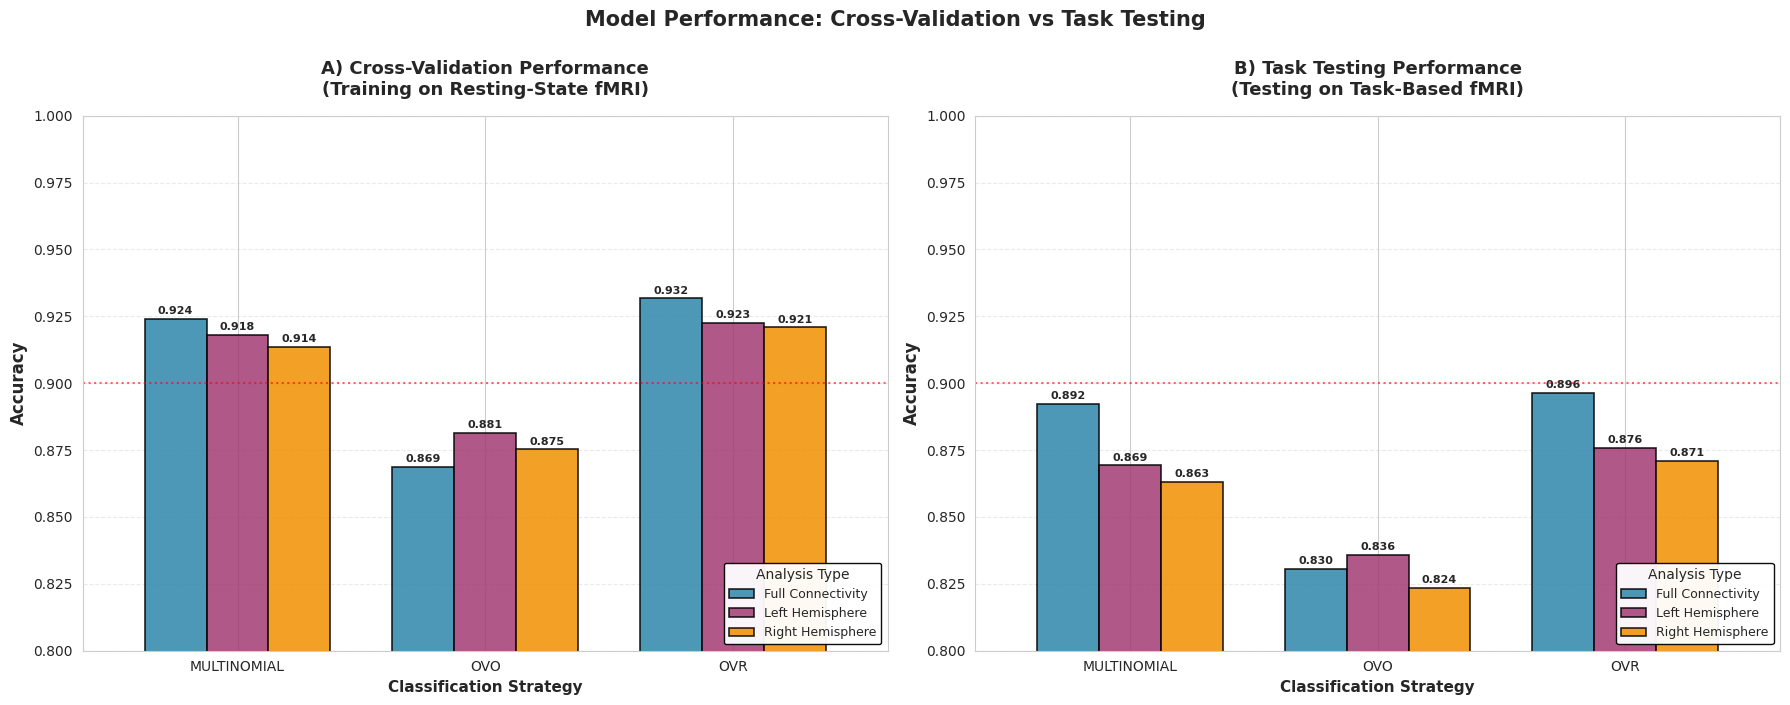

In [94]:
# Combined plot: CV Performance + Task Performance Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define color palette (consistent across both plots)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# LEFT PLOT: CV Performance
ax = axes[0]
cv_plot_data = all_cv_df.pivot(index='Strategy', columns='Analysis', values='Accuracy')
cv_plot_data.plot(kind='bar', ax=ax, width=0.75, color=colors[:len(cv_plot_data.columns)], 
                  edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_title('A) Cross-Validation Performance\n(Training on Resting-State fMRI)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=11, fontweight='bold')
ax.set_ylim([0.80, 1.00])  # Same range for both plots

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2, fontweight='bold')

# Improve legend
ax.legend(title='Analysis Type', fontsize=9, title_fontsize=10, 
          loc='lower right', framealpha=0.95, edgecolor='black')

# Better grid
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Reference line
ax.axhline(y=0.90, color='red', linestyle=':', linewidth=1.5, alpha=0.6)

# RIGHT PLOT: Task Testing Performance
ax = axes[1]
task_plot_data = all_task_df.pivot(index='Strategy', columns='Analysis', values='Accuracy')
task_plot_data.plot(kind='bar', ax=ax, width=0.75, color=colors[:len(task_plot_data.columns)], 
                    edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_title('B) Task Testing Performance\n(Testing on Task-Based fMRI)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=11, fontweight='bold')
ax.set_ylim([0.80, 1.00])  # Same range for both plots

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2, fontweight='bold')

# Improve legend
ax.legend(title='Analysis Type', fontsize=9, title_fontsize=10, 
          loc='lower right', framealpha=0.95, edgecolor='black')

# Better grid
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Reference line
ax.axhline(y=0.90, color='red', linestyle=':', linewidth=1.5, alpha=0.6)

# Add main title for the entire figure
fig.suptitle('Model Performance: Cross-Validation vs Task Testing', 
             fontsize=15, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'cv_vs_task_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(ANALYSIS_OUTPUT_DIR / 'cv_vs_task_performance_comparison.pdf', bbox_inches='tight')
print(f"\nSaved CV vs Task performance comparison plot")
plt.show()

In [79]:
# Performance drop from CV to Task
performance_drop = pd.DataFrame()

for idx, row in all_cv_df.iterrows():
    analysis = row['Analysis']
    strategy = row['Strategy']
    
    # Find matching task performance
    task_row = all_task_df[(all_task_df['Analysis'] == analysis) & 
                            (all_task_df['Strategy'] == strategy)]
    
    if not task_row.empty:
        drop_row = {
            'Analysis': analysis,
            'Strategy': strategy,
            'CV_Accuracy': row['Accuracy'],
            'Task_Accuracy': task_row['Accuracy'].values[0],
            'Accuracy_Drop': row['Accuracy'] - task_row['Accuracy'].values[0],
            'CV_Balanced_Acc': row['Balanced_Accuracy'],
            'Task_Balanced_Acc': task_row['Balanced_Accuracy'].values[0],
            'Balanced_Acc_Drop': row['Balanced_Accuracy'] - task_row['Balanced_Accuracy'].values[0]
        }
        performance_drop = pd.concat([performance_drop, pd.DataFrame([drop_row])], ignore_index=True)

print("\nPerformance Drop (CV to Task):")
print(performance_drop.to_string(index=False))

performance_drop.to_csv(ANALYSIS_OUTPUT_DIR / 'performance_drop_cv_to_task.csv', index=False)
print(f"\nSaved performance drop analysis")


Performance Drop (CV to Task):
         Analysis    Strategy  CV_Accuracy  Task_Accuracy  Accuracy_Drop  CV_Balanced_Acc  Task_Balanced_Acc  Balanced_Acc_Drop
Full Connectivity MULTINOMIAL     0.924126       0.892392       0.031734         0.924126           0.892392           0.031734
Full Connectivity         OVO     0.868785       0.830496       0.038289         0.868785           0.830496           0.038289
Full Connectivity         OVR     0.931708       0.896336       0.035372         0.931708           0.896336           0.035372
  Left Hemisphere MULTINOMIAL     0.918180       0.869310       0.048870         0.918180           0.869310           0.048870
  Left Hemisphere         OVO     0.881427       0.835862       0.045565         0.881427           0.835862           0.045565
  Left Hemisphere         OVR     0.922645       0.875690       0.046955         0.922645           0.875690           0.046955
 Right Hemisphere MULTINOMIAL     0.913562       0.863060       0.050502


Saved performance drop plot


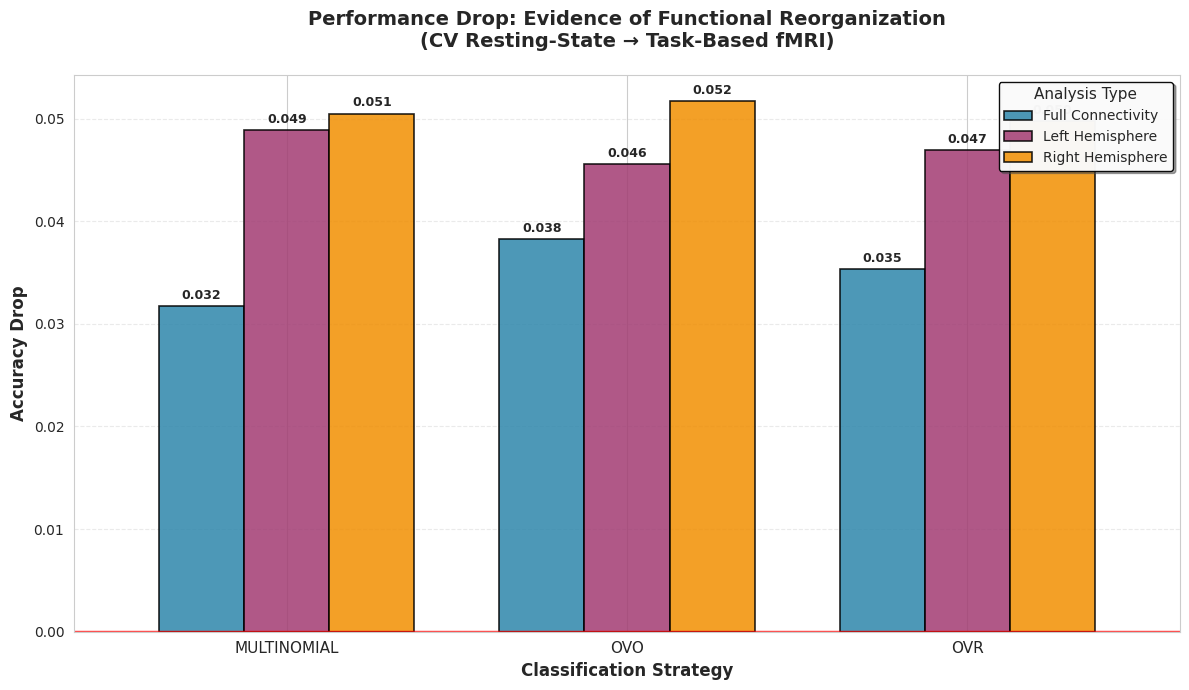

In [95]:
# Plot performance drop - Simplified
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Define color palette (consistent with other plots)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# Prepare data
drop_pivot = performance_drop.pivot(index='Strategy', columns='Analysis', values='Accuracy_Drop')

# Create bar plot
bars = drop_pivot.plot(kind='bar', ax=ax, width=0.75, 
                        color=colors[:len(drop_pivot.columns)], 
                        edgecolor='black', linewidth=1.2, alpha=0.85)

# Customize the plot
ax.set_title('Performance Drop: Evidence of Functional Reorganization\n(CV Resting-State → Task-Based fMRI)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Accuracy Drop', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=12, fontweight='bold')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3, fontweight='bold')

# Zero line (reference for no reorganization)
ax.axhline(y=0, color='red', linestyle='-', linewidth=2.5, alpha=0.7, zorder=1)

# Improve legend
ax.legend(title='Analysis Type', fontsize=10, title_fontsize=11,
          loc='upper right', framealpha=0.95, edgecolor='black', shadow=True)

# Better grid
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Rotate x-axis labels
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'performance_drop.png', dpi=300, bbox_inches='tight')
plt.savefig(ANALYSIS_OUTPUT_DIR / 'performance_drop.pdf', bbox_inches='tight')
print(f"\nSaved performance drop plot")
plt.show()


Saved complete performance analysis plot


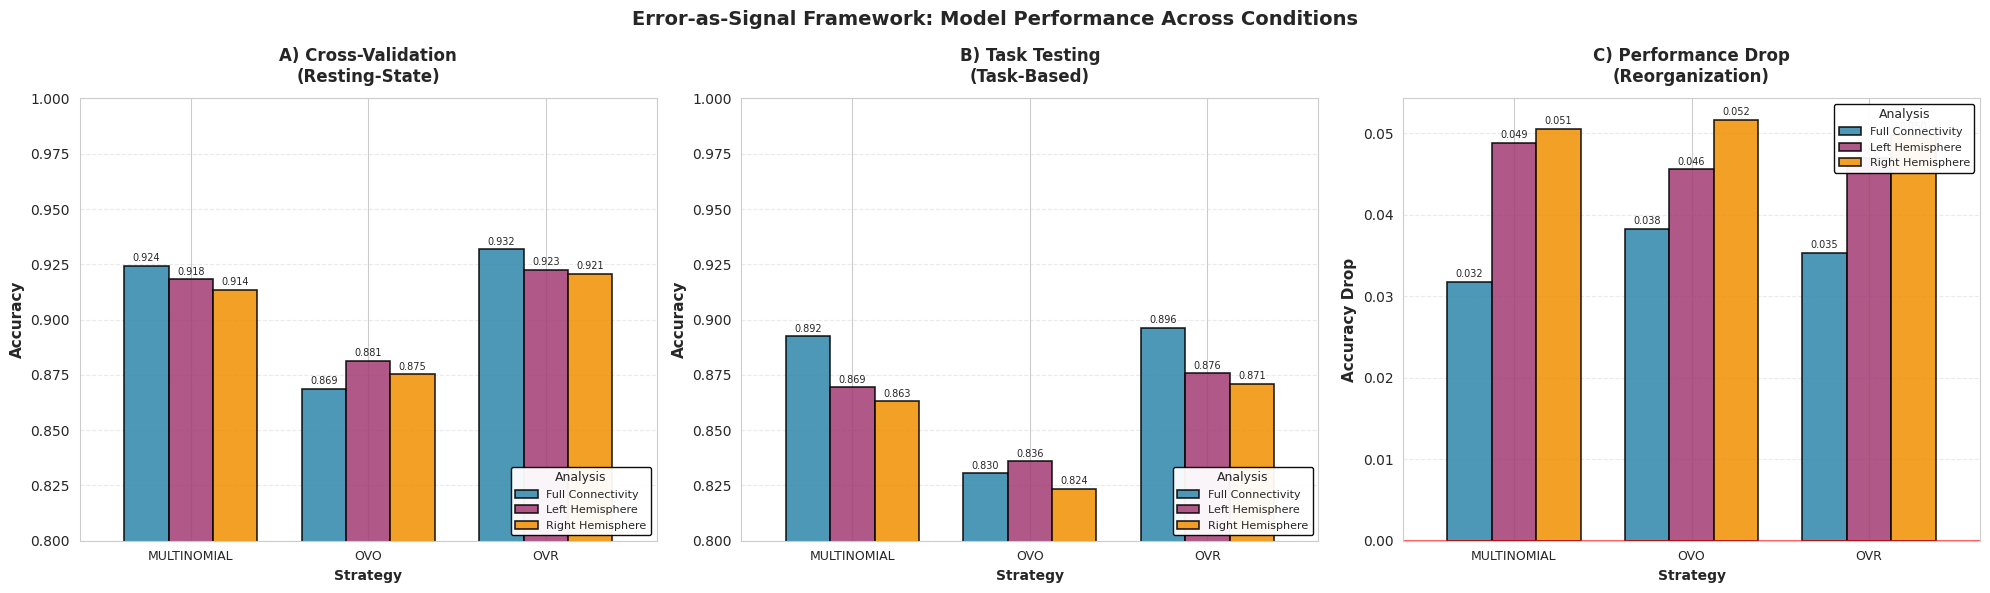

In [99]:
# Triple plot: CV + Task + Performance Drop
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# PLOT 1: CV Performance
ax = axes[0]
cv_plot_data = all_cv_df.pivot(index='Strategy', columns='Analysis', values='Accuracy')
cv_plot_data.plot(kind='bar', ax=ax, width=0.75, color=colors[:len(cv_plot_data.columns)], 
                  edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_title('A) Cross-Validation\n(Resting-State)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=10, fontweight='bold')
ax.set_ylim([0.80, 1.00])  # Changed to 0.8-1.0

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

ax.legend(title='Analysis', fontsize=8, title_fontsize=9, loc='lower right', 
          framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=0, labelsize=9)

# PLOT 2: Task Testing Performance
ax = axes[1]
task_plot_data = all_task_df.pivot(index='Strategy', columns='Analysis', values='Accuracy')
task_plot_data.plot(kind='bar', ax=ax, width=0.75, color=colors[:len(task_plot_data.columns)], 
                    edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_title('B) Task Testing\n(Task-Based)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=10, fontweight='bold')
ax.set_ylim([0.80, 1.00])  # Changed to 0.8-1.0

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

ax.legend(title='Analysis', fontsize=8, title_fontsize=9, loc='lower right', 
          framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=0, labelsize=9)

# PLOT 3: Performance Drop (Reorganization)
ax = axes[2]
drop_pivot = performance_drop.pivot(index='Strategy', columns='Analysis', values='Accuracy_Drop')
drop_pivot.plot(kind='bar', ax=ax, width=0.75, color=colors[:len(drop_pivot.columns)], 
                edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_title('C) Performance Drop\n(Reorganization)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Accuracy Drop', fontsize=11, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=10, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

ax.axhline(y=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax.legend(title='Analysis', fontsize=8, title_fontsize=9, loc='upper right', 
          framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=0, labelsize=9)

# Main title
fig.suptitle('Error-as-Signal Framework: Model Performance Across Conditions', 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'complete_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig(ANALYSIS_OUTPUT_DIR / 'complete_performance_analysis.pdf', bbox_inches='tight')
print(f"\nSaved complete performance analysis plot")
plt.show()

## Summary

In [98]:
print("\n" + "="*80)
print("COMPILATION COMPLETE")
print("="*80)
print(f"\nGenerated files:")
print(f"  - compiled_cv_performance.csv")
print(f"  - compiled_task_performance.csv")
print(f"  - compiled_network_performance.csv")
print(f"  - compiled_region_performance.csv")
print(f"  - performance_drop_cv_to_task.csv")
print(f"  - summary_statistics.json")
print(f"  - cv_performance_comparison.png")
print(f"  - task_performance_comparison.png")
print(f"  - performance_drop.png")
print(f"\nAll files saved to: {ANALYSIS_OUTPUT_DIR}")


COMPILATION COMPLETE

Generated files:
  - compiled_cv_performance.csv
  - compiled_task_performance.csv
  - compiled_network_performance.csv
  - compiled_region_performance.csv
  - performance_drop_cv_to_task.csv
  - summary_statistics.json
  - cv_performance_comparison.png
  - task_performance_comparison.png
  - performance_drop.png

All files saved to: /home/sjoon/projects/brain_connectivity_classifier/data/analysis
